# Logistic Regression

### Dataset : 

https://www.kaggle.com/datasets/mathchi/diabetes-data-set/code

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("resource_old/dataset/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
print("Shape:", df.shape)

Shape: (768, 9)


In [5]:
print("\nColumns:", list(df.columns))


Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [6]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
print("Descriptive stats (numeric):")
print(df.describe().T)

Descriptive stats (numeric):
                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
BloodPressure             768.0   69.105469   19.355807   0.000  62.00000   
SkinThickness             768.0   20.536458   15.952218   0.000   0.00000   
Insulin                   768.0   79.799479  115.244002   0.000   0.00000   
BMI                       768.0   31.992578    7.884160   0.000  27.30000   
DiabetesPedigreeFunction  768.0    0.471876    0.331329   0.078   0.24375   
Age                       768.0   33.240885   11.760232  21.000  24.00000   
Outcome                   768.0    0.348958    0.476951   0.000   0.00000   

                               50%        75%     max  
Pregnancies                 3.0000    6.00000   17.00  
Glucose                   117.0000  140.25000  199.00  
BloodPressure              72.00

In [8]:
target_col = "Outcome"
X = df.drop(columns=[target_col])
y = df[target_col]

In [9]:
print("\nClass distribution (counts):")
print(y.value_counts())


Class distribution (counts):
Outcome
0    500
1    268
Name: count, dtype: int64


In [11]:
zero_counts = (X == 0).sum().sort_values(ascending=False)
print(zero_counts)

Insulin                     374
SkinThickness               227
Pregnancies                 111
BloodPressure                35
BMI                          11
Glucose                       5
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [12]:
print(zero_counts[zero_counts > 0].sort_values(ascending=False))

Insulin          374
SkinThickness    227
Pregnancies      111
BloodPressure     35
BMI               11
Glucose            5
dtype: int64


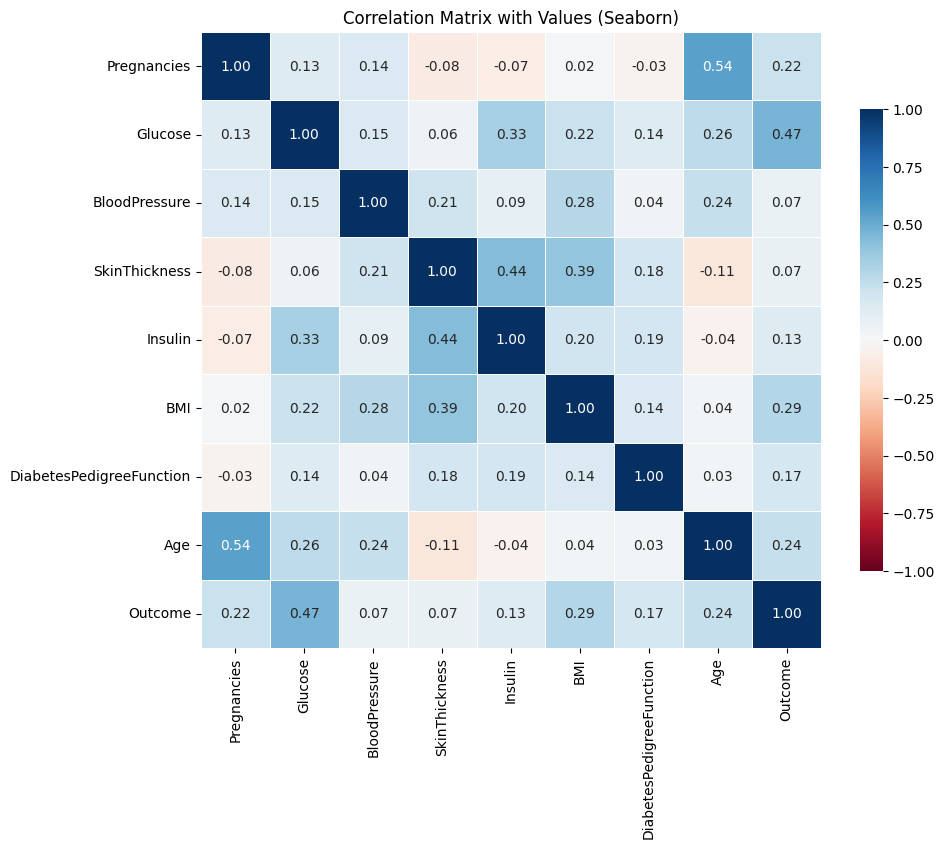

In [13]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, cmap='RdBu',fmt=".2f",vmin=-1,vmax=1,
    center=0,linewidths=.5,cbar_kws={"shrink": .75}
)
plt.title("Correlation Matrix with Values (Seaborn)")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
import numpy as np

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.1, ## taking a 90% train , 10% test split
    random_state=42, 
    stratify=y  ## 
)

In [ ]:
# case 1 with stratify
# 500 - 0, 90% of 500 --> 450(train), 50 is for left test
# 300 - 1, 90% of 300 --> 270(train), 30 is for left test


# # Case 2 with random
# 500 - 0, 490(train), 10 is for left test
# 300 - 1, 100(train), 200 is for left test

In [19]:
print(f"After split -> X_train: {X_train.shape}, X_test: {X_test.shape}")

After split -> X_train: (691, 8), X_test: (77, 8)


In [ ]:
# Step 1 : do the imputation
columns_with_zero = ["Insulin", "SkinThickness", "BloodPressure", "BMI", "Glucose"]

zero_missing_cols = [c for c in columns_with_zero if c in X_train.columns]
print("Columns with 0 for (treating 0 values as missing):", zero_missing_cols)

In [30]:
# Step 2 : scaling
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()


In [31]:
numeric_cols.remove('Pregnancies')

In [33]:
remaining_cols = ['Pregnancies']
remaining_cols

['Pregnancies']

In [34]:
numeric_cols

['Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [36]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.compose import ColumnTransformer

In [38]:
transformers = []

In [39]:
impute_then_scale = SklearnPipeline([
    ("imputer_zero_as_missing", SimpleImputer(missing_values=0, strategy="median")),
    ("scaler", StandardScaler())
])
transformers.append(("impute_scale", impute_then_scale, numeric_cols))


In [40]:
scale_preg = SklearnPipeline([
    ("scaler", StandardScaler()),
])
transformers.append(("scaler_all", scale_preg, remaining_cols))

In [41]:
preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

In [42]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_scale', ...), ('scaler_all', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

# Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
clf = LogisticRegression(solver="liblinear", max_iter=1000, random_state=20)

In [45]:
pipeline = SklearnPipeline([("preprocessor", preprocessor), ("clf", clf)])

In [46]:
pipeline.fit(X_train, y_train)
# preprocessor.fit(X_train)
# preprocessor.transform(X_train)
# clf.fit(X_train)
print("Pipeline fitted to training data.")

Pipeline fitted to training data.


In [47]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_scale', ...), ('scaler_all', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [48]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

In [49]:
y_train_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,

In [50]:
y_test_pred

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0])

In [52]:
## printing the actual probabilities

y_train_proba_diab = pipeline.predict_proba(X_train)[:,1]
y_train_proba_diab
# 0 -> no
# 1, Yes

array([0.1976376 , 0.51285767, 0.40750354, 0.37110858, 0.2121979 ,
       0.17222233, 0.34345745, 0.07219995, 0.76119196, 0.43802145,
       0.25285791, 0.24068666, 0.7661737 , 0.64580758, 0.07632919,
       0.02737029, 0.32464854, 0.41237373, 0.04016081, 0.15469802,
       0.74416947, 0.0350205 , 0.72683883, 0.71382459, 0.20868516,
       0.26841929, 0.69373758, 0.38333659, 0.53893032, 0.74710555,
       0.44490545, 0.49891771, 0.76332564, 0.24368794, 0.06389409,
       0.55734941, 0.07752389, 0.79468262, 0.43145029, 0.10924724,
       0.4282636 , 0.31508917, 0.16243467, 0.59977665, 0.25172709,
       0.42193991, 0.01152105, 0.32808063, 0.38473354, 0.05880356,
       0.03902028, 0.3500831 , 0.05660592, 0.08830839, 0.32807079,
       0.10544249, 0.03126741, 0.10792705, 0.78390777, 0.45640053,
       0.08308126, 0.14193398, 0.25496393, 0.06916754, 0.93114218,
       0.78320255, 0.60383296, 0.14458756, 0.11992156, 0.45022362,
       0.32356989, 0.12359178, 0.06795026, 0.06492742, 0.50350

In [53]:
y_test_proba_diab = pipeline.predict_proba(X_test)[:,1]
y_test_proba_diab

array([0.04721374, 0.68668817, 0.75705139, 0.33971428, 0.11498046,
       0.35770544, 0.73039418, 0.75437203, 0.32052954, 0.52344462,
       0.13301008, 0.30176517, 0.1818103 , 0.02025017, 0.10254376,
       0.92698275, 0.0666113 , 0.85305959, 0.228667  , 0.06831238,
       0.07585059, 0.12312407, 0.03894502, 0.1737577 , 0.05204015,
       0.04980449, 0.25920155, 0.25054662, 0.01219118, 0.22687001,
       0.60794932, 0.69742259, 0.32280258, 0.15538786, 0.99310091,
       0.01825225, 0.62100981, 0.73792066, 0.04353641, 0.10079687,
       0.22273127, 0.62261182, 0.78242913, 0.1373816 , 0.04013881,
       0.74193777, 0.28603531, 0.86796411, 0.83885323, 0.23018755,
       0.46741402, 0.54028546, 0.65639974, 0.32445704, 0.34411965,
       0.94797985, 0.69611076, 0.07319184, 0.32433003, 0.09164704,
       0.08539208, 0.37905441, 0.06673788, 0.64706039, 0.86504006,
       0.0521913 , 0.64944145, 0.44327139, 0.5444432 , 0.67430091,
       0.05907097, 0.33338938, 0.45129182, 0.06445816, 0.26116

In [54]:
(y_train_proba_diab >= 0.9).astype(int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [55]:
train_results = X_train.copy()
train_results['Actual'] = y_train.values
train_results['Predicted'] = y_train_pred
train_results['Predicted_Prob'] = y_train_proba_diab

In [56]:
test_results = X_test.copy()
test_results['Actual'] = y_test.values
test_results['Predicted'] = y_test_pred
test_results['Predicted_Prob'] = y_test_proba_diab

In [57]:
print("TRAIN RESULTS:")
train_results.head()

TRAIN RESULTS:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Predicted_Prob
255,1,113,64,35,0,33.6,0.543,21,1,0,0.197638
125,1,88,30,42,99,55.0,0.496,26,1,1,0.512858
46,1,146,56,0,0,29.7,0.564,29,0,0,0.407504
312,2,155,74,17,96,26.6,0.433,27,1,0,0.371109
519,6,129,90,7,326,19.6,0.582,60,0,0,0.212198


In [58]:
print("TEST RESULTS:")
test_results.head()

TEST RESULTS:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Predicted_Prob
158,2,88,74,19,53,29.0,0.229,22,0,0,0.047214
484,0,145,0,0,0,44.2,0.630,31,1,1,0.686688
712,10,129,62,36,0,41.2,0.441,38,1,1,0.757051
535,4,132,0,0,0,32.9,0.302,23,1,0,0.339714
205,5,111,72,28,0,23.9,0.407,27,0,0,0.114980


In [59]:
test_results[test_results['Actual'] != test_results['Predicted']]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual,Predicted,Predicted_Prob
535,4,132,0,0,0,32.9,0.302,23,1,0,0.339714
517,7,125,86,0,0,37.6,0.304,51,0,1,0.523445
17,7,107,74,0,0,29.6,0.254,31,1,0,0.181810
366,6,124,72,0,0,27.6,0.368,29,1,0,0.250547
44,7,159,64,0,0,27.4,0.294,40,0,1,0.607949
699,4,118,70,0,0,44.5,0.904,26,0,1,0.621010
558,11,103,68,40,0,46.2,0.126,42,0,1,0.622612
258,1,193,50,16,375,25.9,0.655,24,0,1,0.741938
264,4,123,62,0,0,32.0,0.226,35,1,0,0.286035
469,6,154,78,41,140,46.1,0.571,27,0,1,0.867964


In [60]:
test_results[test_results['Actual'] != test_results['Predicted']].shape

(21, 11)

In [61]:
test_results.groupby(['Actual', 'Predicted']).size()

Actual  Predicted
0       0            40
        1            10
1       0            11
        1            16
dtype: int64

In [62]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, confusion_matrix, classification_report
)

In [63]:
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "ROC-AUC Score" : roc_auc_score(y_true, y_pred),
        "classification_report": classification_report(y_true, y_pred, output_dict=True)
    }

In [64]:
metrics_train = compute_metrics(y_train, y_train_pred)
print("TRAIN metrics:")
for k,v in metrics_train.items():
    if k not in ("confusion_matrix", "classification_report"):
        print(f"  {k}: {v:.4f}")

TRAIN metrics:
  accuracy: 0.7800
  precision: 0.7380
  recall: 0.5726
  f1: 0.6449
  ROC-AUC Score: 0.7319


In [65]:
metrics_test = compute_metrics(y_test, y_test_pred)
print("TEST metrics:")
for k,v in metrics_test.items():
    if k not in ("confusion_matrix", "classification_report"):
        print(f"  {k}: {v:.4f}")

TEST metrics:
  accuracy: 0.7273
  precision: 0.6154
  recall: 0.5926
  f1: 0.6038
  ROC-AUC Score: 0.6963


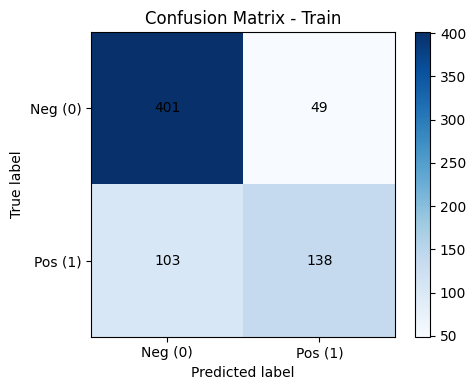

In [66]:
# Confusion matrices
cm_train = metrics_train["confusion_matrix"]
plt.figure(figsize=(5,4))
plt.imshow(cm_train, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Train")
plt.colorbar()
plt.xticks([0,1], ["Neg (0)", "Pos (1)"])
plt.yticks([0,1], ["Neg (0)", "Pos (1)"])
for i in range(cm_train.shape[0]):
    for j in range(cm_train.shape[1]):
        plt.text(j, i, cm_train[i,j], ha="center", va="center")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

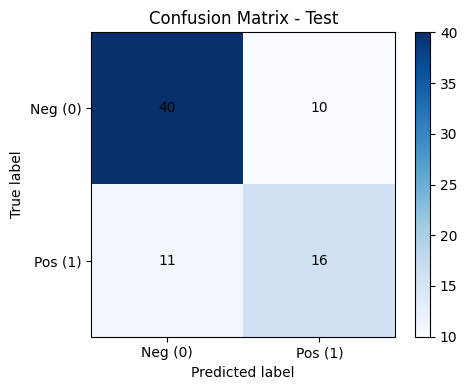

In [67]:
cm_test = metrics_test["confusion_matrix"]
plt.figure(figsize=(5,4))
plt.imshow(cm_test, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Test")
plt.colorbar()
plt.xticks([0,1], ["Neg (0)", "Pos (1)"])
plt.yticks([0,1], ["Neg (0)", "Pos (1)"])
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        plt.text(j, i, cm_test[i,j], ha="center", va="center")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()